### Folder selection

In [1]:
from PyQt6.QtWidgets import QApplication, QFileDialog
import sys

def select_folder_pyqt6():
    # Create application
    app = QApplication(sys.argv)

    # Open folder dialog
    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select a folder",
        ""
    )

    # Close QApplication
    app.exit()

    return folder_path

path = select_folder_pyqt6()
print(f"path: {path}")

path: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20251205_1913_BMF44-B-1_d31_rotation


### Select fitting strategy

In [2]:
from shg_analysis import SHGDataAnalysis
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analysis = SHGDataAnalysis(path)
meta = analysis.meta
data = analysis.data

crystal = CRYSTALS[meta["material"]]()

if crystal.axiality == "uniaxial":
    from fitting_strategies.jerphagnon1970 import Jerphagnon1970Strategy
    strategy = Jerphagnon1970Strategy(analysis)

elif crystal.axiality == "biaxial":
    from fitting_strategies.ishidate1974 import Ishidate1974Strategy
    strategy = Ishidate1974Strategy(analysis)

### Check theoretical maker fringe equation

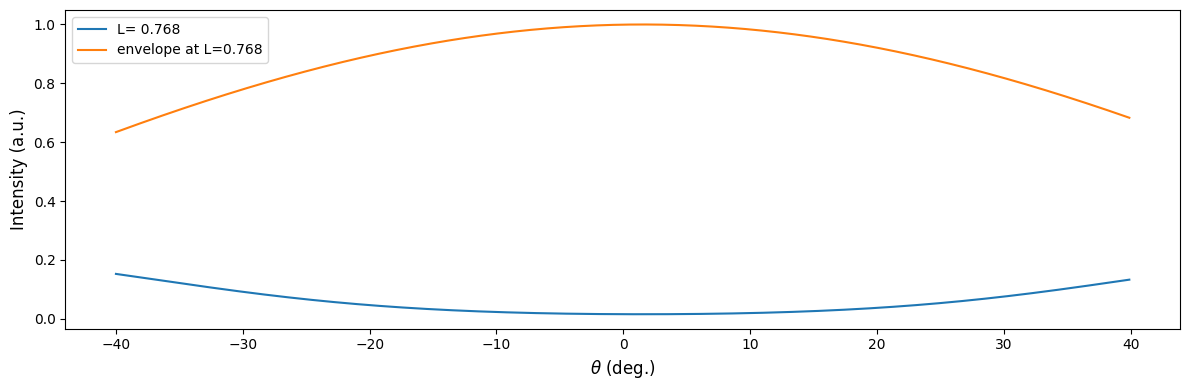

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = analysis.data["position"]


plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

for i in [0.768]:
    fringe = strategy._maker_fringes(override={"L":i})
    envelope = strategy._maker_fringes(override={"L":i}, envelope=True)
    ax.plot(x, fringe, label=f'L= {i}')
    ax.plot(x, envelope, label=f'envelope at L={i}')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 3.2)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Phase matching angle for BMF d31

xyz -> bca
theta = 90 deg, phi = 11.65 deg

#### incident angle for theta_p_w to be 11.65 deg

In [4]:
n_w_a = strategy.n_eff(0, 1064)
n_w_a_check = crystal.get_n(1064, "a")

phi_deg = 11.65
phi = np.deg2rad(phi_deg)
n_2w_b = crystal.get_n(532, "b")
n_2w_c = crystal.get_n(532, "c")
n_2w_phi = n_2w_b * n_2w_c / np.sqrt((n_2w_b * np.cos(phi))**2 + (n_2w_c * np.sin(phi))**2)

theta_pm = np.arcsin(n_2w_phi * np.sin(phi))
theta_pm_deg = np.rad2deg(theta_pm)

n_2w_phi_check = strategy.n_eff(90, 532, theta_pm_deg)

print(f"\
    n_w: {n_w_a}\n\
    n_w_check: {n_w_a_check}\n\
    n_2w_phi: {n_2w_phi}\n\
    n_2w_check: {n_2w_phi_check}\n\
    "
)
print(f"crystal angle at pm: {theta_pm_deg}")

    n_w: 1.4667722906398473
    n_w_check: 1.4667722906398473
    n_2w_phi: 1.4667724064313425
    n_2w_check: 1.466772406431342
    
crystal angle at pm: 17.228866140834636
